# Test YOLOv11 OBB ONNX Model
Debug model output format and class mapping

In [1]:
import onnxruntime as ort
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

## 1. Load Model and Inspect

In [4]:
# Load ONNX model
model_path = r"C:\Code\APPAutoVRS\BE-AutoVRS\models\singleclass_model\BamDinhKhongTot\weights\best.onnx"
session = ort.InferenceSession(model_path, providers=['CPUExecutionProvider'])

# Get model info
print("=" * 60)
print("MODEL INFO")
print("=" * 60)

# Inputs
print("\n📥 INPUTS:")
for inp in session.get_inputs():
    print(f"  Name: {inp.name}")
    print(f"  Shape: {inp.shape}")
    print(f"  Type: {inp.type}")

# Outputs
print("\n📤 OUTPUTS:")
for out in session.get_outputs():
    print(f"  Name: {out.name}")
    print(f"  Shape: {out.shape}")
    print(f"  Type: {out.type}")

# Metadata
print("\n📋 METADATA:")
meta = session.get_modelmeta()
print(f"  Producer: {meta.producer_name}")
print(f"  Version: {meta.version}")
print(f"  Description: {meta.description}")
print(f"  Custom metadata: {meta.custom_metadata_map}")

MODEL INFO

📥 INPUTS:
  Name: images
  Shape: [1, 3, 640, 640]
  Type: tensor(float)

📤 OUTPUTS:
  Name: output0
  Shape: [1, 6, 8400]
  Type: tensor(float)

📋 METADATA:
  Producer: pytorch
  Version: 9223372036854775807
  Description: 
  Custom metadata: {'date': '2026-01-14T15:29:42.096092', 'description': 'Ultralytics YOLO11s-obb model trained on E:\\data\\OBBDatasetTrain_Fitbox\\singleclass_datasets\\BamDinhKhongTot\\data.yaml', 'author': 'Ultralytics', 'version': '8.3.229', 'task': 'obb', 'license': 'AGPL-3.0 License (https://ultralytics.com/license)', 'docs': 'https://docs.ultralytics.com', 'stride': '32', 'batch': '1', 'imgsz': '[640, 640]', 'names': "{0: 'BamDinhKhongTot'}", 'args': "{'batch': 1, 'fraction': 1.0, 'half': False, 'int8': False, 'dynamic': False, 'simplify': True, 'nms': False}", 'channels': '3'}


## 2. Load and Preprocess Image

✅ Loaded image: (1024, 1280, 3) (H, W, C)
✅ Preprocessed: (1, 3, 640, 640) (B, C, H, W)
   Ratio: 0.5, Padding: (0.0, 64.0)


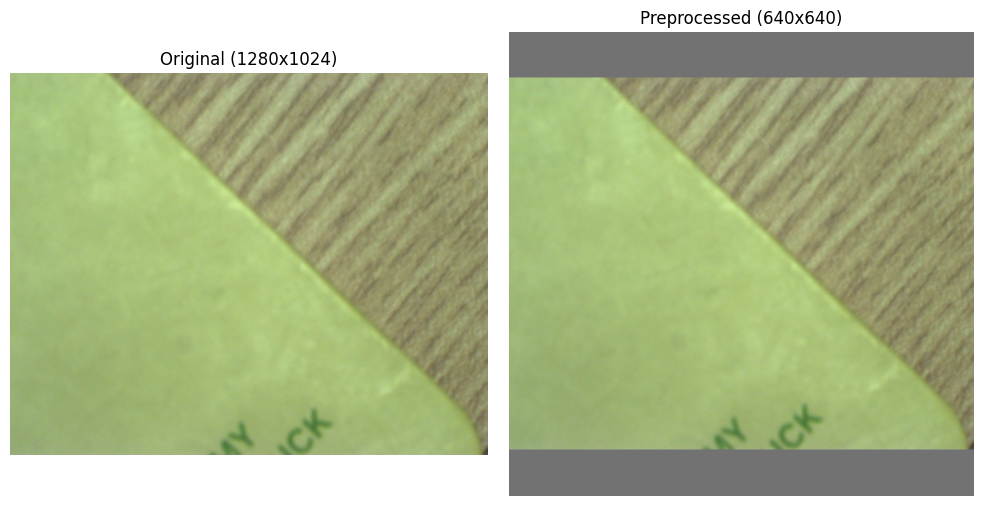

In [3]:
def letterbox(img, new_shape=(640, 640), color=(114, 114, 114)):
    """Resize and pad image to square with letterbox"""
    shape = img.shape[:2]  # current shape [height, width]
    
    # Scale ratio (new / old)
    r = min(new_shape[0] / shape[0], new_shape[1] / shape[1])
    
    # Compute padding
    new_unpad = int(round(shape[1] * r)), int(round(shape[0] * r))
    dw, dh = new_shape[1] - new_unpad[0], new_shape[0] - new_unpad[1]
    dw /= 2  # divide padding into 2 sides
    dh /= 2
    
    if shape[::-1] != new_unpad:  # resize
        img = cv2.resize(img, new_unpad, interpolation=cv2.INTER_LINEAR)
    
    top, bottom = int(round(dh - 0.1)), int(round(dh + 0.1))
    left, right = int(round(dw - 0.1)), int(round(dw + 0.1))
    img = cv2.copyMakeBorder(img, top, bottom, left, right, cv2.BORDER_CONSTANT, value=color)
    
    return img, r, (dw, dh)

# Load image
image_path = r"C:\Code\APPAutoVRS\BE-AutoVRS\Image_input\ai_input_20251222_154611.jpg"
image = cv2.imread(image_path)
print(f"✅ Loaded image: {image.shape} (H, W, C)")

# Store original for later
orig_img = image.copy()
orig_h, orig_w = image.shape[:2]

# Preprocess
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
image_resized, ratio, (pad_w, pad_h) = letterbox(image_rgb, (640, 640))

# Normalize and transpose to CHW
image_norm = image_resized.astype(np.float32) / 255.0
image_chw = np.transpose(image_norm, (2, 0, 1))  # HWC -> CHW
image_batch = np.expand_dims(image_chw, axis=0)  # Add batch dimension

print(f"✅ Preprocessed: {image_batch.shape} (B, C, H, W)")
print(f"   Ratio: {ratio}, Padding: ({pad_w}, {pad_h})")

# Display
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(orig_img, cv2.COLOR_BGR2RGB))
plt.title(f"Original ({orig_w}x{orig_h})")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(image_resized)
plt.title("Preprocessed (640x640)")
plt.axis('off')
plt.tight_layout()
plt.show()

## 3. Run Inference and Inspect Output

In [ ]:
# Run inference
input_name = session.get_inputs()[0].name
output_names = [out.name for out in session.get_outputs()]

print("🚀 Running inference...")
outputs = session.run(output_names, {input_name: image_batch})

print(f"\n✅ Got {len(outputs)} output tensor(s)")
for i, out in enumerate(outputs):
    print(f"\n📊 Output {i}:")
    print(f"   Shape: {out.shape}")
    print(f"   Dtype: {out.dtype}")
    print(f"   Min: {out.min():.4f}")
    print(f"   Max: {out.max():.4f}")
    print(f"   Mean: {out.mean():.4f}")

## 4. Parse Output Format

YOLOv11 OBB format:
- Output shape: **(1, num_features, 8400)**
- num_features = 15 + num_classes
  - First 4: bbox center (x, y, w, h)
  - Next 8: OBB corners (x1,y1,x2,y2,x3,y3,x4,y4) 
  - Next 1: objectness/confidence
  - Last N: class probabilities (N = num_classes)
  
For 11 classes: num_features = 15 + 11 = 26

In [ ]:
# Get main output
output = outputs[0]  # Shape: (1, features, 8400)
print(f"Raw output shape: {output.shape}")

# Transpose to (8400, features)
output = output[0].T  # Remove batch dim and transpose
num_boxes, num_features = output.shape
print(f"After transpose: {output.shape} - {num_boxes} boxes, {num_features} features")

# Determine structure
num_classes = num_features - 15  # 15 = 4 (bbox) + 8 (obb) + 1 (obj) + 2 (angle?)
print(f"\n📋 Format Analysis:")
print(f"   Features per box: {num_features}")
print(f"   Estimated classes: {num_classes}")
print(f"   Expected classes: 11 (from data.yaml)")

# Show first detection breakdown
print(f"\n🔍 First Detection Breakdown:")
first_det = output[0]
print(f"   Indices 0-3 (bbox): {first_det[0:4]}")
print(f"   Indices 4-11 (OBB 8 coords): {first_det[4:12]}")
print(f"   Index 12 (confidence?): {first_det[12]}")
print(f"   Indices 13-14: {first_det[13:15]}")
if num_features > 15:
    print(f"   Indices 15+ (classes, {num_features-15} values):")
    print(f"      {first_det[15:]}")
    print(f"      Max class prob: {first_det[15:].max():.4f} at index {first_det[15:].argmax()}")

## 5. Filter and Parse Detections

In [ ]:
# Configuration
CONF_THRESHOLD = 0.25
CLASS_NAMES = [
    "BamDinhKhongTot",      # 0
    "DiVat",                # 1
    "DiVatDuongMach",       # 2
    "KhuyetMach",           # 3
    "NganMach",             # 4
    "ThieuDong",            # 5
    "ThieuDongDuongMach",   # 6
    "ThuaDong",             # 7
    "ThuaDongDuongMach",    # 8
    "VetLom",               # 9
    "Xuoc",                 # 10
]

def parse_yolo11_obb(output, conf_threshold=0.25, ratio=1.0, pad=(0, 0)):
    """
    Parse YOLOv11 OBB output
    
    Args:
        output: shape (num_boxes, num_features)
        conf_threshold: confidence threshold
        ratio: resize ratio for coordinate scaling
        pad: padding (pad_w, pad_h)
    
    Returns:
        list of detections
    """
    detections = []
    
    # Try different index schemes
    # Scheme 1: conf at index 12, classes at 15+
    for box in output:
        conf = box[12]  # Try objectness at index 12
        
        if conf < conf_threshold:
            continue
        
        # Get OBB coordinates (indices 4-11)
        obb_coords = box[4:12].copy()
        
        # Scale back to original image
        obb_coords[0::2] = (obb_coords[0::2] - pad[0]) / ratio  # x coords
        obb_coords[1::2] = (obb_coords[1::2] - pad[1]) / ratio  # y coords
        
        # Get class
        class_probs = box[15:15+11]  # Assuming 11 classes
        class_id = int(np.argmax(class_probs))
        class_conf = class_probs[class_id]
        
        detections.append({
            'obb': obb_coords.reshape(4, 2),  # 4 corners
            'confidence': float(conf),
            'class_id': class_id,
            'class_name': CLASS_NAMES[class_id] if class_id < len(CLASS_NAMES) else f'class_{class_id}',
            'class_prob': float(class_conf)
        })
    
    return detections

# Parse detections
detections = parse_yolo11_obb(output, CONF_THRESHOLD, ratio, (pad_w, pad_h))

print(f"\n✅ Found {len(detections)} detections (conf > {CONF_THRESHOLD})\n")
for i, det in enumerate(detections):
    print(f"Detection {i+1}:")
    print(f"  Class: {det['class_name']} (id={det['class_id']})")
    print(f"  Confidence: {det['confidence']:.3f}")
    print(f"  Class prob: {det['class_prob']:.3f}")
    print(f"  OBB corners: {det['obb']}")
    print()

## 6. Visualize Results

In [ ]:
# Draw detections on image
vis_img = orig_img.copy()

for det in detections:
    # Get OBB corners
    corners = det['obb'].astype(np.int32)
    
    # Draw polygon
    cv2.polylines(vis_img, [corners], True, (0, 255, 0), 2)
    
    # Draw label
    label = f"{det['class_name']} {det['confidence']:.2f}"
    x, y = corners[0]
    cv2.putText(vis_img, label, (x, y-5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

# Display
plt.figure(figsize=(15, 10))
plt.imshow(cv2.cvtColor(vis_img, cv2.COLOR_BGR2RGB))
plt.title(f"Detected {len(detections)} defects")
plt.axis('off')
plt.tight_layout()
plt.show()

# Save result
output_path = r"C:\Code\APPAutoVRS\BE-AutoVRS\Image_output\onnx_test_result.jpg"
cv2.imwrite(output_path, vis_img)
print(f"✅ Saved result to: {output_path}")

## 7. Debug: Try Different Confidence Index

In [ ]:
# Check different indices for confidence
print("🔍 Trying different confidence indices:\n")

for conf_idx in [8, 12, 13, 14]:
    print(f"Confidence at index {conf_idx}:")
    confidences = output[:, conf_idx]
    high_conf = confidences[confidences > 0.1]
    print(f"  Min: {confidences.min():.4f}, Max: {confidences.max():.4f}")
    print(f"  Values > 0.1: {len(high_conf)}")
    if len(high_conf) > 0:
        print(f"  Sample values: {high_conf[:5]}")
    print()

## Summary

Run all cells to:
1. See model input/output structure
2. Understand raw output format
3. Parse detections correctly
4. Visualize results

**Key findings will help fix the main code!**